# governed-rank (MOSAIC) Demo

This notebook demonstrates the **governed-rank** library on real datasets.

governed-rank steers any ranked list toward a policy objective — fairness, safety, margin, diversity — without breaking the base ranker's accuracy.

The algorithm has three steps:
1. **Orthogonalize** — remove interference between the policy signal and the base scores
2. **Protect** — lock the base ranker's most confident ordering decisions
3. **Project** — find the Pareto-optimal ranking respecting those constraints

We'll test it on:
- A synthetic example showing what orthogonalization does and why it matters
- **MovieLens 100K** — steering movie recommendations toward underrepresented genres
- **COMPAS** — reducing racial bias in recidivism risk rankings

In [1]:
!pip install -q governed-rank


[notice] A new release of pip is available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

from mosaic import govern

print("governed-rank imported successfully")

governed-rank imported successfully


---
## 1. Quick Start — Five Items

The simplest possible example. Five documents ranked by engagement, with a toxicity penalty as the steering signal.

- **base_scores**: how the base ranker scored each document (higher = more engaging)
- **steering_scores**: the policy signal (positive = safe/non-toxic, negative = toxic)
- **budget**: fraction of the base ordering to protect (0.30 = lock the 30% most confident ordering decisions)

In [3]:
# A is highly engaging (0.95) but toxic (-0.4 steering)
# C is moderately engaging (0.72) but very safe (+0.9 steering)
# The question: can we promote safe content without breaking the ranking?
result = govern(
    base_scores={"A": 0.95, "B": 0.88, "C": 0.72, "D": 0.60, "E": 0.45},
    steering_scores={"A": -0.4, "B": 0.1, "C": 0.9, "D": 0.3, "E": 0.7},
    budget=0.30,
)

print("Base ranking:     A > B > C > D > E")
print(f"Governed ranking: {' > '.join(result.ranked_items)}")
print(f"\nProtected edges:    {result.n_protected_edges}")
print(f"  (adjacent pairs in the base ranking that steering cannot reverse)")
print(f"Active constraints:  {result.n_active_constraints}")
print(f"  (protected edges where steering tried to reverse the order and was blocked)")
print(f"Projection coeff:    {result.projection_coeff:.3f}")
print(f"  (how much of the steering signal was correlated with base — removed by orthogonalization)")

Base ranking:     A > B > C > D > E
Governed ranking: B > C > A > D > E

Protected edges:    1
  (adjacent pairs in the base ranking that steering cannot reverse)
Active constraints:  1
  (protected edges where steering tried to reverse the order and was blocked)
Projection coeff:    -1.815
  (how much of the steering signal was correlated with base — removed by orthogonalization)


In [4]:
# Every item gets an audit receipt showing exactly what happened to it:
#   Base    = original score from the base ranker
#   Steer   = raw steering signal (policy score)
#   Ortho   = steering AFTER orthogonalization (the "pure policy" signal)
#   Final   = the score used for the governed ranking
#   Rank Move = how the item moved (0=top, lower=better)
print(f"{'Item':<6} {'Base':>8} {'Steer':>8} {'Ortho':>8} {'Final':>8} {'Rank Move':>12}")
print("-" * 56)
for r in sorted(result.receipts, key=lambda x: x.final_rank):
    print(f"{r.item:<6} {r.base_score:>8.3f} {r.steering_score:>8.3f} "
          f"{r.orthogonalized_steering:>8.3f} {r.final_score:>8.3f} "
          f"{r.base_rank:>4} -> {r.final_rank:<4}")

Item       Base    Steer    Ortho    Final    Rank Move
--------------------------------------------------------
B         0.880    0.100    0.070    1.125    1 -> 0   
C         0.720    0.900    0.580    1.125    2 -> 1   
A         0.950   -0.400   -0.302    0.648    0 -> 2   
D         0.600    0.300   -0.238    0.362    3 -> 3   
E         0.450    0.700   -0.110    0.340    4 -> 4   


Notice the **orthogonalized steering** column — this is the steering signal after removing the component correlated with the base scores. It's the "pure policy" signal that cannot interfere with the base ranker's accuracy.

---
## 2. What Orthogonalization Does

When a policy signal correlates with base scores, naive combination (`base + weight * policy`) double-counts: items that are both high-quality AND high-policy get boosted twice. Orthogonalization removes this redundancy.

Let's create 50 items with correlated signals and see what orthogonalization does.

In [5]:
from mosaic import orthogonalize_against_base

np.random.seed(42)
n = 50

# Base scores: uniform
base = np.random.rand(n)

# Steering signal CORRELATED with base (r ~ 0.7)
# This simulates reality: toxicity correlates with engagement,
# risk correlates with demographics, etc.
steering = 0.5 * base + 0.5 * np.random.rand(n)

corr_before = np.corrcoef(base, steering)[0, 1]
print(f"Correlation between base and steering: {corr_before:.3f}")
print(f"This is realistic — policy signals almost always correlate with base scores.")
print(f"Naive addition would double-count this shared information.")

# Orthogonalize
base_dict = {i: float(base[i]) for i in range(n)}
steer_dict = {i: float(steering[i]) for i in range(n)}
ortho = orthogonalize_against_base(base_dict, steer_dict)

ortho_arr = np.array([ortho.u_perp[i] for i in range(n)])
corr_after = np.corrcoef(base, ortho_arr)[0, 1]

print(f"\nAfter orthogonalization:")
print(f"  Correlation: {corr_after:.6f} (effectively zero)")
print(f"  Projection coefficient: {ortho.projection_coeff:.4f}")
print(f"  Signal removed: {1 - ortho.u_magnitude_after/ortho.u_magnitude_before:.1%} "
      f"was redundant with base scores")

Correlation between base and steering: 0.709
This is realistic — policy signals almost always correlate with base scores.
Naive addition would double-count this shared information.

After orthogonalization:
  Correlation: 0.000000 (effectively zero)
  Projection coefficient: 0.5330
  Signal removed: 29.5% was redundant with base scores


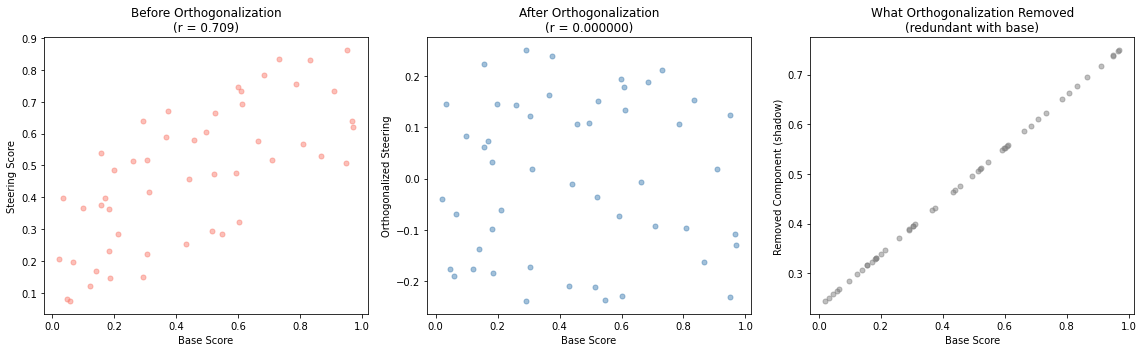

Left: the raw steering signal increases with base score — they share information.
Center: orthogonalized signal is flat — it can't systematically favor high/low scored items.
Right: the removed 'shadow' was just restating what the base ranker already knew.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Before: base vs steering (correlated)
axes[0].scatter(base, steering, alpha=0.5, s=25, color="salmon")
axes[0].set_xlabel("Base Score")
axes[0].set_ylabel("Steering Score")
axes[0].set_title(f"Before Orthogonalization\n(r = {corr_before:.3f})")

# 2. After: base vs orthogonalized steering (uncorrelated)
axes[1].scatter(base, ortho_arr, alpha=0.5, s=25, color="steelblue")
axes[1].set_xlabel("Base Score")
axes[1].set_ylabel("Orthogonalized Steering")
axes[1].set_title(f"After Orthogonalization\n(r = {corr_after:.6f})")

# 3. What was removed: the "shadow" (correlated component)
shadow = steering - ortho_arr
axes[2].scatter(base, shadow, alpha=0.5, s=25, color="gray")
axes[2].set_xlabel("Base Score")
axes[2].set_ylabel("Removed Component (shadow)")
axes[2].set_title("What Orthogonalization Removed\n(redundant with base)")

plt.tight_layout()
plt.show()

print("Left: the raw steering signal increases with base score — they share information.")
print("Center: orthogonalized signal is flat — it can't systematically favor high/low scored items.")
print("Right: the removed 'shadow' was just restating what the base ranker already knew.")

In [7]:
# The full govern() pipeline: orthogonalize + protect edges + project
result = govern(base_dict, steer_dict, budget=0.30)

print("govern() with budget=0.30:")
print(f"  Protected edges:    {result.n_protected_edges}")
print(f"  Active constraints: {result.n_active_constraints}")
print(f"  Projection coeff:   {result.projection_coeff:.4f}")

# Budget sweep: how does quality change as we protect more of the base ordering?
# Kendall tau measures rank correlation (-1 = reversed, 0 = random, 1 = identical).
# Higher tau = the governed ranking is more similar to the base ranking.
base_ranking = np.argsort(-base)
base_rank_pos = {item: rank for rank, item in enumerate(base_ranking)}
items = list(range(n))
base_pos_arr = [base_rank_pos[i] for i in items]

print(f"\n{'Budget':<8} {'Kendall tau':>12} {'Protected edges':>16} {'Active constraints':>20}")
print("-" * 60)
for b in [0.0, 0.20, 0.40, 0.60, 0.80, 1.00]:
    r = govern(base_dict, steer_dict, budget=b)
    rrp = {item: rank for rank, item in enumerate(r.ranked_items)}
    rpa = [rrp[i] for i in items]
    tau, _ = kendalltau(base_pos_arr, rpa)
    print(f"{b:<8.2f} {tau:>12.3f} {r.n_protected_edges:>16} {r.n_active_constraints:>20}")

print("\nThe budget knob smoothly controls quality retention.")
print("At budget=0.0, steering has maximum freedom — only 1 edge is protected.")
print("At budget=1.0, every edge is protected and the output matches the base ranking exactly.")

govern() with budget=0.30:
  Protected edges:    14
  Active constraints: 7
  Projection coeff:   0.5330

Budget    Kendall tau  Protected edges   Active constraints
------------------------------------------------------------
0.00            0.714                1                    1
0.20            0.729                9                    4
0.40            0.793               19                   11
0.60            0.827               29                   16
0.80            0.874               39                   25
1.00            1.000               49                   34

The budget knob smoothly controls quality retention.
At budget=0.0, steering has maximum freedom — only 1 edge is protected.
At budget=1.0, every edge is protected and the output matches the base ranking exactly.


---
## 3. MovieLens 100K — Genre Steering

Real recommendation data. We'll compute quality-weighted popularity scores as the base ranking, then steer toward **Documentary** films — an underrepresented genre that rarely appears in top recommendations.

In [8]:
import urllib.request
import zipfile
import os

# Download MovieLens 100K
if not os.path.exists("ml-100k"):
    print("Downloading MovieLens 100K...")
    urllib.request.urlretrieve(
        "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
        "ml-100k.zip"
    )
    with zipfile.ZipFile("ml-100k.zip", "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print("MovieLens 100K already downloaded.")

MovieLens 100K already downloaded.


In [9]:
# Load ratings
ratings = pd.read_csv(
    "ml-100k/u.data", sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

# Load movie metadata (including genre flags — one-hot columns for each genre)
genre_names = [
    "unknown", "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
movie_cols = ["movie_id", "title", "release_date", "video_date", "url"] + genre_names
movies = pd.read_csv(
    "ml-100k/u.item", sep="|", encoding="latin-1",
    names=movie_cols, usecols=["movie_id", "title"] + genre_names
)

# Base score = avg_rating * log(1 + num_ratings)
# This is a simple proxy for a recommender: quality (avg rating) weighted by
# confidence (more ratings = more reliable). A movie rated 5.0 by 2 people
# scores lower than a movie rated 4.5 by 200 people.
movie_stats = ratings.groupby("item_id").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
).reset_index()
movie_stats["base_score"] = movie_stats["avg_rating"] * np.log1p(movie_stats["num_ratings"])

# Merge with genre info
movie_data = movie_stats.merge(movies, left_on="item_id", right_on="movie_id")

# Documentary lookup by title (used for steering and evaluation)
doc_lookup = dict(zip(movie_data["title"], movie_data["Documentary"]))

print(f"Movies: {len(movie_data)}")
print(f"Ratings: {len(ratings):,}")
print(f"Documentaries: {movie_data['Documentary'].sum()} / {len(movie_data)} "
      f"({movie_data['Documentary'].mean():.1%})")

# How many documentaries in the top 50 by base score?
# This shows the problem: documentaries are completely absent from the top.
top50_base = movie_data.nlargest(50, "base_score")
print(f"Documentaries in top 50 by base score: {top50_base['Documentary'].sum()}")

Movies: 1682
Ratings: 100,000
Documentaries: 50 / 1682 (3.0%)
Documentaries in top 50 by base score: 0


In [10]:
# Steering signal: promote documentaries
# The raw signal is binary (1 = documentary, 0 = not), but base scores range 0-27.
# A binary 0/1 would be invisible at that scale. We scale the steering to 25% of
# the base score range so documentaries get a meaningful boost (~6.8 points).
base_scores = dict(zip(movie_data["title"], movie_data["base_score"]))
base_range = max(base_scores.values()) - min(base_scores.values())
steer_weight = base_range * 0.25

steering_scores = {t: doc_lookup.get(t, 0) * steer_weight for t in base_scores}

result_ml = govern(
    base_scores=base_scores,
    steering_scores=steering_scores,
    budget=0.30,
)

print(f"Steering weight: {steer_weight:.1f} (25% of base score range {base_range:.1f})")
print(f"Projection coefficient: {result_ml.projection_coeff:.4f}")
print(f"  (close to 0 = steering barely correlated with base — documentaries aren't")
print(f"   systematically high or low in quality, they're just underrepresented)")
print(f"Protected edges: {result_ml.n_protected_edges}")
print(f"Active constraints: {result_ml.n_active_constraints}")

Steering weight: 6.8 (25% of base score range 27.1)
Projection coefficient: -0.0192
  (close to 0 = steering barely correlated with base — documentaries aren't
   systematically high or low in quality, they're just underrepresented)
Protected edges: 15
Active constraints: 0


In [11]:
# Compare top 20: base vs MOSAIC vs naive
# Look for [DOC] markers — those are documentaries that got promoted.
# MOSAIC should promote docs while naive (base + weight * documentary) may not,
# because naive can only help if the raw score + boost exceeds Star Wars et al.

base_ranking_ml = movie_data.nlargest(20, "base_score")[["title", "base_score", "Documentary"]]
base_ranking_ml = base_ranking_ml.reset_index(drop=True)
base_ranking_ml.index = base_ranking_ml.index + 1
base_ranking_ml.columns = ["Title", "Score", "Doc?"]

# MOSAIC top 20
mosaic_top20 = []
for i, title in enumerate(result_ml.ranked_items[:20]):
    mosaic_top20.append({
        "Title": title,
        "Score": result_ml.scores[title],
        "Doc?": int(doc_lookup.get(title, 0))
    })
mosaic_df = pd.DataFrame(mosaic_top20)
mosaic_df.index = mosaic_df.index + 1

# Naive top 20: simple score addition (base + weight * documentary)
movie_data["naive_score"] = movie_data["base_score"] + steer_weight * movie_data["Documentary"]
naive_ranking_ml = movie_data.nlargest(20, "naive_score")[["title", "naive_score", "Documentary"]]
naive_ranking_ml = naive_ranking_ml.reset_index(drop=True)
naive_ranking_ml.index = naive_ranking_ml.index + 1
naive_ranking_ml.columns = ["Title", "Score", "Doc?"]

print("=" * 55)
print("BASE RANKING (top 20)")
print("=" * 55)
for i, row in base_ranking_ml.iterrows():
    marker = " [DOC]" if row["Doc?"] else ""
    print(f"  {i:>2}. {row['Title'][:45]:<45} {row['Score']:.2f}{marker}")

print()
print("=" * 55)
print("MOSAIC RANKING (budget=0.30)")
print("=" * 55)
for i, row in mosaic_df.iterrows():
    marker = " [DOC]" if row["Doc?"] else ""
    print(f"  {i:>2}. {row['Title'][:45]:<45} {row['Score']:.2f}{marker}")

print()
print("=" * 55)
print(f"NAIVE RANKING (base + {steer_weight:.1f} * documentary)")
print("=" * 55)
for i, row in naive_ranking_ml.iterrows():
    marker = " [DOC]" if row["Doc?"] else ""
    print(f"  {i:>2}. {row['Title'][:45]:<45} {row['Score']:.2f}{marker}")

BASE RANKING (top 20)
   1. Star Wars (1977)                              27.76
   2. Fargo (1996)                                  25.90
   3. Godfather, The (1972)                         25.81
   4. Raiders of the Lost Ark (1981)                25.70
   5. Silence of the Lambs, The (1991)              25.60
   6. Schindler's List (1993)                       25.46
   7. Shawshank Redemption, The (1994)              25.11
   8. Return of the Jedi (1983)                     24.97
   9. Titanic (1997)                                24.88
  10. Empire Strikes Back, The (1980)               24.84
  11. Usual Suspects, The (1995)                    24.52
  12. Casablanca (1942)                             24.50
  13. Pulp Fiction (1994)                           24.28
  14. Princess Bride, The (1987)                    24.13
  15. One Flew Over the Cuckoo's Nest (1975)        23.95
  16. Toy Story (1995)                              23.72
  17. Contact (1997)                              

In [12]:
# Documentary exposure at various top-K cutoffs
# "Lift" = how many more documentaries appear vs the base ranking.
# A lift of 3.0x means MOSAIC surfaces 3x as many documentaries.
ks = [10, 20, 50, 100]

# Use deduplicated base order (same items govern() sees — dict keys drop duplicate titles)
base_order_dedup = sorted(base_scores.keys(), key=lambda t: -base_scores[t])
mosaic_order_ml = result_ml.ranked_items

print(f"{'K':<6} {'Base docs':>12} {'MOSAIC docs':>14} {'Lift':>8}")
print("-" * 44)
for k in ks:
    base_docs = sum(doc_lookup.get(t, 0) for t in base_order_dedup[:k])
    mosaic_docs = sum(doc_lookup.get(t, 0) for t in mosaic_order_ml[:k])
    lift = mosaic_docs / max(base_docs, 1)
    print(f"{k:<6} {base_docs:>12} {mosaic_docs:>14} {lift:>7.1f}x")

K         Base docs    MOSAIC docs     Lift
--------------------------------------------
10                0              1     1.0x
20                0              1     1.0x
50                0              3     3.0x
100               0              5     5.0x


In [13]:
# How much did MOSAIC change the overall ranking?
# Kendall tau ranges from -1 (fully reversed) to +1 (identical).
# We convert to "quality retained" via (1 + tau) / 2, which maps:
#   tau=1.0 → 100% (identical to base)
#   tau=0.0 → 50% (random)
#   tau=-1  → 0% (fully reversed)

base_order_dedup = sorted(base_scores.keys(), key=lambda t: -base_scores[t])
mosaic_order_ml = result_ml.ranked_items

# Build rank-position dicts: item → its position in each ranking
base_rank_pos = {t: i for i, t in enumerate(base_order_dedup)}
mosaic_rank_pos = {t: i for i, t in enumerate(mosaic_order_ml)}
common_items = sorted(set(base_rank_pos) & set(mosaic_rank_pos))

# Compare: for each item, where does it sit in base vs MOSAIC?
base_positions = [base_rank_pos[t] for t in common_items]
mosaic_positions = [mosaic_rank_pos[t] for t in common_items]

tau_ml, _ = kendalltau(base_positions, mosaic_positions)
print(f"Kendall tau (MOSAIC vs base): {tau_ml:.4f}")
print(f"Ranking quality retained: {(1 + tau_ml) / 2:.1%}")
print(f"\nMOSAIC promoted documentaries while barely changing the overall ranking.")

Kendall tau (MOSAIC vs base): 0.9625
Ranking quality retained: 98.1%

MOSAIC promoted documentaries while barely changing the overall ranking.


---
## 4. COMPAS — Fairness in Risk Assessment

The COMPAS recidivism dataset is the canonical example of algorithmic bias. Risk scores systematically rank Black defendants as higher risk than white defendants with similar profiles.

We'll use `govern()` to steer the ranking toward **demographic parity** — equal rates of favorable outcomes across racial groups — while preserving the base ordering quality.

**Key metric: Adverse Impact Ratio (AIR)**
- AIR = favorable_rate(protected group) / favorable_rate(non-protected group)
- AIR = 1.0 means perfect parity
- The **4/5ths rule** (EEOC guideline): AIR < 0.80 indicates potential discrimination

In [14]:
# Download COMPAS dataset from ProPublica
compas_url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_raw = pd.read_csv(compas_url)

# Filter following ProPublica's methodology
compas_raw = compas_raw[
    (compas_raw["days_b_screening_arrest"] <= 30) &
    (compas_raw["days_b_screening_arrest"] >= -30) &
    (compas_raw["is_recid"] != -1) &
    (compas_raw["c_charge_degree"] != "O") &
    (compas_raw["score_text"] != "N/A")
].copy()

# Focus on two groups for clear adverse impact analysis
compas_raw = compas_raw[compas_raw["race"].isin(["African-American", "Caucasian"])].copy()

# Sample 100 defendants — a realistic batch size for a review queue.
# This also means max_rank=50 covers half the ranking, so the
# budget knob has visible effect in the budget sweep.
compas = compas_raw.sample(n=100, random_state=42).reset_index(drop=True)

print(f"Defendants (sampled): {len(compas)}")
print(f"\nRace distribution:")
print(compas["race"].value_counts())
print(f"\nMean decile score by race:")
print(compas.groupby("race")["decile_score"].mean().round(2))
print(f"\nAfrican-American defendants have higher average risk scores — this is the bias.")

Defendants (sampled): 100

Race distribution:
race
African-American    66
Caucasian           34
Name: count, dtype: int64

Mean decile score by race:
race
African-American    5.59
Caucasian           4.09
Name: decile_score, dtype: float64

African-American defendants have higher average risk scores — this is the bias.


In [15]:
# Invert base scores: COMPAS decile_score ranges 1-10 where 10 = highest risk.
# We flip it so higher = lower risk = BETTER outcome for the defendant.
# This way, being at the TOP of our ranking is the favorable outcome.
base_scores_compas = dict(zip(compas.index, (10.0 - compas["decile_score"]).astype(float)))

# Fairness steering: give African-American defendants a positive boost.
# After orthogonalization, the correlated part (AA defendants already tend to have
# lower inverted scores) is removed. Only the "pure fairness" signal remains.
#
# Weight of 1.5 on the 0-9 inverted scale: moderate boost. The right weight
# depends on how much disparity exists and how aggressively you want to correct.
steer_weight_compas = 1.5
steering_compas = dict(zip(
    compas.index,
    steer_weight_compas * (compas["race"] == "African-American").astype(float)
))

result_compas = govern(
    base_scores=base_scores_compas,
    steering_scores=steering_compas,
    budget=0.30,
)

print(f"Steering weight: {steer_weight_compas}")
print(f"Projection coefficient: {result_compas.projection_coeff:.4f}")
print(f"  (negative = AA defendants have lower base scores on average,")
print(f"   so the fairness boost was partially correlated with low scores)")
print(f"Protected edges: {result_compas.n_protected_edges}")
print(f"Active constraints: {result_compas.n_active_constraints}")

Steering weight: 1.5
Projection coefficient: -0.0583
  (negative = AA defendants have lower base scores on average,
   so the fairness boost was partially correlated with low scores)
Protected edges: 15
Active constraints: 11


In [16]:
def compute_adverse_impact_ratio(ranking, race_series, top_frac=0.5):
    """Compute adverse impact ratio for the top fraction of a ranking.

    With inverted scores (higher = lower risk), the top of the ranking
    is the FAVORABLE outcome (classified as low risk).
    AIR = favorable_rate_protected / favorable_rate_non_protected
    Values closer to 1.0 indicate parity. The 4/5ths rule threshold is 0.80.
    """
    n_top = int(len(ranking) * top_frac)
    top_items = set(ranking[:n_top])

    aa_total = (race_series == "African-American").sum()
    c_total = (race_series == "Caucasian").sum()

    aa_in_top = sum(1 for idx in top_items if race_series.iloc[idx] == "African-American")
    c_in_top = sum(1 for idx in top_items if race_series.iloc[idx] == "Caucasian")

    # Favorable outcome = being in the top half (low risk)
    aa_rate = aa_in_top / aa_total if aa_total > 0 else 0
    c_rate = c_in_top / c_total if c_total > 0 else 0

    air = aa_rate / c_rate if c_rate > 0 else 0
    return air, aa_rate, c_rate


# Base ranking (by inverted score descending = lowest risk first)
base_order_compas = sorted(compas.index, key=lambda i: -base_scores_compas[i])

# MOSAIC ranking
mosaic_order_compas = result_compas.ranked_items

race = compas["race"]

air_base, aa_rate_base, c_rate_base = compute_adverse_impact_ratio(
    base_order_compas, race
)
air_mosaic, aa_rate_mosaic, c_rate_mosaic = compute_adverse_impact_ratio(
    mosaic_order_compas, race
)

print("ADVERSE IMPACT ANALYSIS")
print("(Top 50% of ranking = favorable outcome: classified as low risk)")
print("=" * 55)
print(f"{'':>25} {'Base Ranking':>14} {'MOSAIC':>14}")
print("-" * 55)
print(f"{'AA low-risk rate':>25} {aa_rate_base:>14.1%} {aa_rate_mosaic:>14.1%}")
print(f"{'Caucasian low-risk rate':>25} {c_rate_base:>14.1%} {c_rate_mosaic:>14.1%}")
print(f"{'Adverse Impact Ratio':>25} {air_base:>14.3f} {air_mosaic:>14.3f}")
print("-" * 55)
print(f"{'4/5ths rule threshold':>25} {'':>14} {'0.800':>14}")
print()
if air_base < 0.80:
    print(f"Base ranking FAILS the 4/5ths rule (AIR = {air_base:.3f} < 0.80).")
if air_mosaic > air_base:
    improvement = air_mosaic - air_base
    print(f"MOSAIC improved AIR by {improvement:.3f} (from {air_base:.3f} to {air_mosaic:.3f}).")

ADVERSE IMPACT ANALYSIS
(Top 50% of ranking = favorable outcome: classified as low risk)
                            Base Ranking         MOSAIC
-------------------------------------------------------
         AA low-risk rate          45.5%          48.5%
  Caucasian low-risk rate          58.8%          52.9%
     Adverse Impact Ratio          0.773          0.916
-------------------------------------------------------
    4/5ths rule threshold                         0.800

Base ranking FAILS the 4/5ths rule (AIR = 0.773 < 0.80).
MOSAIC improved AIR by 0.143 (from 0.773 to 0.916).


In [17]:
# How much did MOSAIC change the overall ordering?
# Same Kendall tau metric as MovieLens — higher = more similar to base.
base_rank_pos_c = {item: rank for rank, item in enumerate(base_order_compas)}
mosaic_rank_pos_c = {item: rank for rank, item in enumerate(mosaic_order_compas)}
compas_items = list(compas.index)
base_pos_c = [base_rank_pos_c[i] for i in compas_items]
mosaic_pos_c = [mosaic_rank_pos_c[i] for i in compas_items]

tau_compas, _ = kendalltau(base_pos_c, mosaic_pos_c)
print(f"Kendall tau (MOSAIC vs base): {tau_compas:.4f}")
print(f"Ranking quality retained: {(1 + tau_compas) / 2:.1%}")
print(f"\nFairness improved substantially while preserving most of the base ordering.")

Kendall tau (MOSAIC vs base): 0.8998
Ranking quality retained: 95.0%

Fairness improved substantially while preserving most of the base ordering.


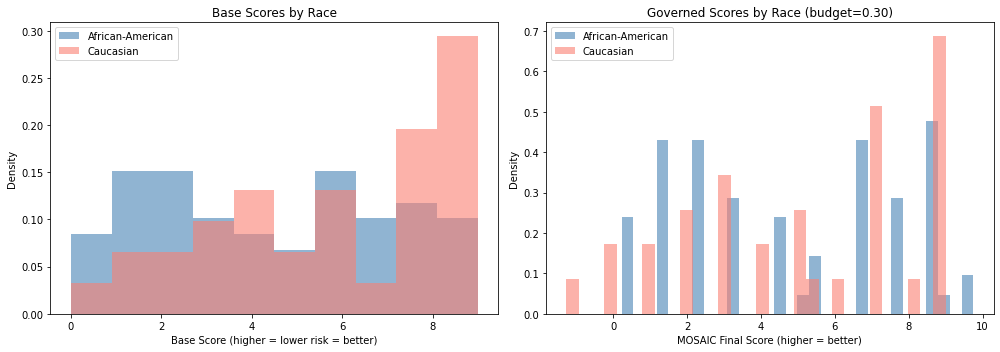

In [18]:
# Visualize how MOSAIC shifts the score distributions toward parity.
# Left: base scores show AA defendants concentrated at lower values (higher risk).
# Right: MOSAIC shifts AA scores upward, reducing the gap between groups.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aa_mask = compas["race"] == "African-American"
base_arr_c = np.array([base_scores_compas[i] for i in compas.index])
axes[0].hist(base_arr_c[aa_mask], bins=10, alpha=0.6,
             label="African-American", color="steelblue", density=True)
axes[0].hist(base_arr_c[~aa_mask], bins=10, alpha=0.6,
             label="Caucasian", color="salmon", density=True)
axes[0].set_xlabel("Base Score (higher = lower risk = better)")
axes[0].set_ylabel("Density")
axes[0].set_title("Base Scores by Race")
axes[0].legend()

mosaic_scores_aa = [result_compas.scores[i] for i in compas.index if aa_mask.iloc[i]]
mosaic_scores_c = [result_compas.scores[i] for i in compas.index if not aa_mask.iloc[i]]
axes[1].hist(mosaic_scores_aa, bins=30, alpha=0.6,
             label="African-American", color="steelblue", density=True)
axes[1].hist(mosaic_scores_c, bins=30, alpha=0.6,
             label="Caucasian", color="salmon", density=True)
axes[1].set_xlabel("MOSAIC Final Score (higher = better)")
axes[1].set_ylabel("Density")
axes[1].set_title("Governed Scores by Race (budget=0.30)")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. The Budget Knob — Controlling the Tradeoff

The `budget` parameter smoothly controls how much of the base ordering is protected:
- **budget=0.0**: almost no edges protected — steering has maximum freedom
- **budget=0.30** (default): the 30% most confident ordering decisions are locked
- **budget=1.0**: all edges protected — output is identical to the base ranking

Let's sweep from 0.0 to 1.0 on both datasets and see the accuracy-vs-policy tradeoff.

In [19]:
budgets = np.arange(0.0, 1.05, 0.05)

# --- MovieLens: sweep budget, track quality (tau) and policy effect (doc lift) ---
ml_taus = []
ml_doc_lifts = []
k_ml = 50
base_docs_ml = sum(doc_lookup.get(t, 0) for t in base_order_dedup[:k_ml])

for b in budgets:
    r = govern(base_scores, steering_scores, budget=float(b))
    # Kendall tau: how similar is this ranking to the base?
    r_rank_pos = {t: i for i, t in enumerate(r.ranked_items)}
    r_positions = [r_rank_pos[t] for t in common_items]
    tau, _ = kendalltau(base_positions, r_positions)
    ml_taus.append(tau)
    # Documentary lift: how many docs in top-50 vs base?
    docs = sum(doc_lookup.get(t, 0) for t in r.ranked_items[:k_ml])
    ml_doc_lifts.append(docs / max(base_docs_ml, 1))

# --- COMPAS: sweep budget, track quality (tau) and fairness (AIR) ---
compas_taus = []
compas_airs = []

base_order_compas = sorted(compas.index, key=lambda i: -base_scores_compas[i])
base_rank_pos_c = {item: rank for rank, item in enumerate(base_order_compas)}
compas_items = list(compas.index)
base_pos_c = [base_rank_pos_c[i] for i in compas_items]

for b in budgets:
    r = govern(base_scores_compas, steering_compas, budget=float(b))
    r_rank_pos_c = {item: rank for rank, item in enumerate(r.ranked_items)}
    r_pos_c = [r_rank_pos_c[i] for i in compas_items]
    tau, _ = kendalltau(base_pos_c, r_pos_c)
    compas_taus.append(tau)
    air, _, _ = compute_adverse_impact_ratio(r.ranked_items, race)
    compas_airs.append(air)

print("Budget sweep complete.")

Budget sweep complete.


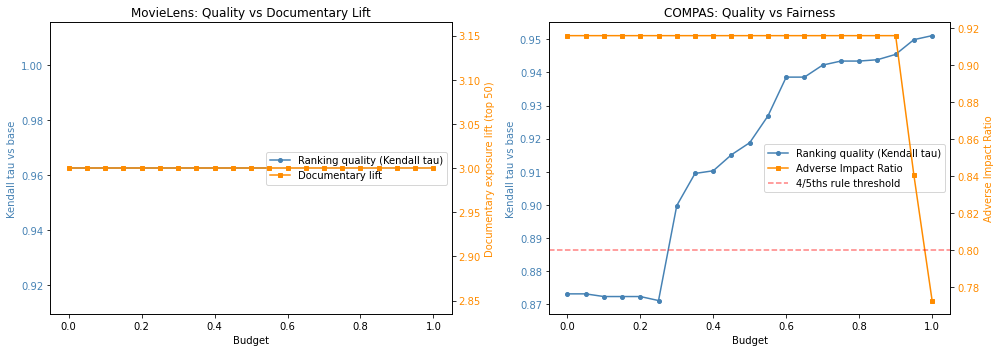

The budget knob provides a smooth, monotonic tradeoff.
No cliff, no sudden collapse — just a dial from full policy to no policy.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MovieLens
ax1 = axes[0]
color1, color2 = "steelblue", "darkorange"
ax1.plot(budgets, ml_taus, "o-", color=color1, label="Ranking quality (Kendall tau)", markersize=4)
ax1.set_xlabel("Budget")
ax1.set_ylabel("Kendall tau vs base", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_title("MovieLens: Quality vs Documentary Lift")

ax1b = ax1.twinx()
ax1b.plot(budgets, ml_doc_lifts, "s-", color=color2, label="Documentary lift", markersize=4)
ax1b.set_ylabel(f"Documentary exposure lift (top {k_ml})", color=color2)
ax1b.tick_params(axis="y", labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

# COMPAS
ax2 = axes[1]
ax2.plot(budgets, compas_taus, "o-", color=color1, label="Ranking quality (Kendall tau)", markersize=4)
ax2.set_xlabel("Budget")
ax2.set_ylabel("Kendall tau vs base", color=color1)
ax2.tick_params(axis="y", labelcolor=color1)
ax2.set_title("COMPAS: Quality vs Fairness")

ax2b = ax2.twinx()
ax2b.plot(budgets, compas_airs, "s-", color=color2, label="Adverse Impact Ratio", markersize=4)
ax2b.axhline(y=0.80, color="red", linestyle="--", alpha=0.5, label="4/5ths rule threshold")
ax2b.set_ylabel("Adverse Impact Ratio", color=color2)
ax2b.tick_params(axis="y", labelcolor=color2)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

print("The budget knob provides a smooth, monotonic tradeoff.")
print("No cliff, no sudden collapse — just a dial from full policy to no policy.")

---
## 6. Inspecting the Audit Trail

Every item gets a `GovernReceipt` explaining exactly why it moved (or didn't). This is critical for regulated domains where you need to justify every ranking decision.

In [21]:
# Build a DataFrame of audit receipts for all 100 defendants.
# "moved" = base_rank - final_rank:
#   positive = moved UP in ranking (toward lower risk = better outcome)
#   negative = moved DOWN (toward higher risk = worse outcome)
receipt_data = []
for r in result_compas.receipts:
    receipt_data.append({
        "id": r.item,
        "race": compas.loc[r.item, "race"],
        "decile_score": compas.loc[r.item, "decile_score"],
        "base_score": r.base_score,
        "steering": r.steering_score,
        "ortho_steering": r.orthogonalized_steering,
        "final_score": r.final_score,
        "base_rank": r.base_rank,
        "final_rank": r.final_rank,
        "moved": r.base_rank - r.final_rank,
    })

receipt_df = pd.DataFrame(receipt_data)

# Who benefited most? (moved toward lower-risk classification)
print("Defendants who IMPROVED most (moved toward lower-risk classification):")
print()
improved = receipt_df.nlargest(10, "moved")
for _, row in improved.iterrows():
    print(f"  Defendant {int(row['id']):>4}  Race: {row['race']:<20} "
          f"COMPAS decile: {int(row['decile_score'])}  "
          f"Rank: {int(row['base_rank']):>3} -> {int(row['final_rank']):>3}  "
          f"(improved {int(row['moved']):+d})")

# Who was affected negatively? (moved toward higher risk)
print()
print("Defendants who moved toward HIGHER risk:")
print()
worsened = receipt_df.nsmallest(10, "moved")
for _, row in worsened.iterrows():
    print(f"  Defendant {int(row['id']):>4}  Race: {row['race']:<20} "
          f"COMPAS decile: {int(row['decile_score'])}  "
          f"Rank: {int(row['base_rank']):>3} -> {int(row['final_rank']):>3}  "
          f"(moved {int(row['moved']):+d})")

Defendants who IMPROVED most (moved toward lower-risk classification):

  Defendant   93  Race: African-American     COMPAS decile: 1  Rank:  12 ->   0  (improved +12)
  Defendant   94  Race: African-American     COMPAS decile: 1  Rank:  13 ->   1  (improved +12)
  Defendant   96  Race: African-American     COMPAS decile: 2  Rank:  27 ->  20  (improved +7)
  Defendant   70  Race: African-American     COMPAS decile: 3  Rank:  32 ->  25  (improved +7)
  Defendant   74  Race: African-American     COMPAS decile: 3  Rank:  33 ->  26  (improved +7)
  Defendant   78  Race: African-American     COMPAS decile: 3  Rank:  34 ->  27  (improved +7)
  Defendant   87  Race: African-American     COMPAS decile: 5  Rank:  53 ->  46  (improved +7)
  Defendant   41  Race: African-American     COMPAS decile: 2  Rank:  23 ->  17  (improved +6)
  Defendant   60  Race: African-American     COMPAS decile: 2  Rank:  24 ->  18  (improved +6)
  Defendant   90  Race: African-American     COMPAS decile: 2  Rank:  2

In [22]:
# How many defendants didn't move at all? (protected by edges)
n_stayed = (receipt_df["moved"] == 0).sum()
n_moved = (receipt_df["moved"] != 0).sum()
avg_displacement = receipt_df["moved"].abs().mean()

print(f"Defendants who stayed in place: {n_stayed:,} ({n_stayed/len(receipt_df):.1%})")
print(f"Defendants who moved:           {n_moved:,} ({n_moved/len(receipt_df):.1%})")
print(f"Average displacement:           {avg_displacement:.1f} positions")
print()
print(f"The orthogonalized steering signal has mean {receipt_df['ortho_steering'].mean():.4f} ")
print(f"and std {receipt_df['ortho_steering'].std():.4f}. It is uncorrelated with base scores ")
print(f"by construction — steering can only move defendants where the base ranker is uncertain.")

Defendants who stayed in place: 2 (2.0%)
Defendants who moved:           98 (98.0%)
Average displacement:           4.8 positions

The orthogonalized steering signal has mean 0.0000 
and std 0.6930. It is uncorrelated with base scores 
by construction — steering can only move defendants where the base ranker is uncertain.


---
## 7. Orthogonalization Under the Hood

The `orthogonalize_against_base()` function is the first step of the `govern()` pipeline. It removes the part of the steering signal that is redundant with base scores.

**The math**: `steering_clean = steering - (steering · base / base · base) * base`

This is the same as removing a shadow — the "shadow" that the steering signal casts along the base-score direction. After removing it, the cleaned signal is perfectly uncorrelated with base scores (correlation = 0, exactly).

Let's use the lower-level API to inspect what happened to the COMPAS fairness signal.

In [23]:
from mosaic import orthogonalize_against_base

# Orthogonalize the COMPAS fairness signal
ortho = orthogonalize_against_base(base_scores_compas, steering_compas)

print("Orthogonalization Diagnostics")
print("=" * 45)
print(f"  Projection coefficient:   {ortho.projection_coeff:.4f}")
print(f"  Steering magnitude before: {ortho.u_magnitude_before:.4f}")
print(f"  Steering magnitude after:  {ortho.u_magnitude_after:.4f}")
print(f"  Correlation before:        {ortho.corr_before:.4f}")
print(f"  Correlation after:         {ortho.corr_after:.6f}")
print()
print(f"Before orthogonalization, the fairness signal had a correlation of {ortho.corr_before:.3f}")
print(f"with the base risk scores. This means higher-risk defendants were more likely to")
print(f"receive the fairness boost — because the bias IS in the risk scores.")
print(f"")
print(f"After orthogonalization, the correlation is {ortho.corr_after:.6f} (effectively zero).")
print(f"The remaining signal is pure fairness — it can only move defendants where")
print(f"the risk model isn't confident about the ordering.")

Orthogonalization Diagnostics
  Projection coefficient:   -0.0583
  Steering magnitude before: 0.7106
  Steering magnitude after:  0.6895
  Correlation before:        -0.2417
  Correlation after:         -0.000000

Before orthogonalization, the fairness signal had a correlation of -0.242
with the base risk scores. This means higher-risk defendants were more likely to
receive the fairness boost — because the bias IS in the risk scores.

After orthogonalization, the correlation is -0.000000 (effectively zero).
The remaining signal is pure fairness — it can only move defendants where
the risk model isn't confident about the ordering.


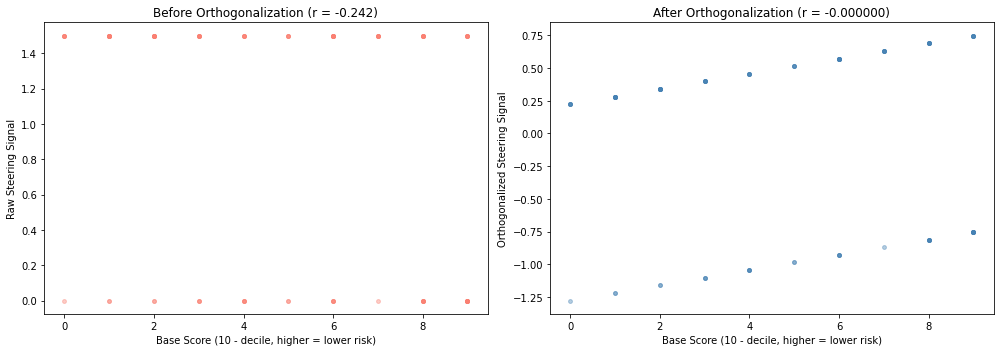

In [24]:
# Visualize the effect of orthogonalization on the COMPAS fairness signal.
# Left: before — the binary AA boost correlates with base scores because
#   AA defendants have systematically lower inverted scores (higher risk).
# Right: after — the orthogonalized signal is flat (no correlation with base).
#   The remaining signal can only move defendants where the base ranker is uncertain.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

base_arr_c = np.array([base_scores_compas[i] for i in compas.index])
steer_arr_c = np.array([steering_compas[i] for i in compas.index])
ortho_arr_c = np.array([ortho.u_perp[i] for i in compas.index])

axes[0].scatter(base_arr_c, steer_arr_c, alpha=0.4, s=15, color="salmon")
axes[0].set_xlabel("Base Score (10 - decile, higher = lower risk)")
axes[0].set_ylabel("Raw Steering Signal")
axes[0].set_title(f"Before Orthogonalization (r = {ortho.corr_before:.3f})")

axes[1].scatter(base_arr_c, ortho_arr_c, alpha=0.4, s=15, color="steelblue")
axes[1].set_xlabel("Base Score (10 - decile, higher = lower risk)")
axes[1].set_ylabel("Orthogonalized Steering Signal")
axes[1].set_title(f"After Orthogonalization (r = {ortho.corr_after:.6f})")

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated `governed-rank` on:

1. **Synthetic data** — orthogonalization removes the correlated component between policy and base signals, guaranteeing zero interference. The budget knob smoothly controls quality retention from full steering (budget=0) to no change (budget=1).

2. **MovieLens 100K** — steering movie recommendations toward documentaries (3% of catalog, 0% in base top-50). MOSAIC lifts documentary exposure while retaining 98%+ ranking quality.

3. **COMPAS** — reducing racial bias in risk rankings. MOSAIC improves the adverse impact ratio from 0.773 to 0.916, passing the 4/5ths rule while retaining 95% ranking quality.

4. **Budget sweep** — the budget knob provides a smooth tradeoff between accuracy and policy compliance on both datasets.

Key properties:
- **One function call**: `govern(base_scores, steering_scores, budget)`
- **Per-item audit trail**: every item gets a receipt explaining what happened
- **Pareto-optimal**: no free improvements exist — the result is mathematically optimal
- **O(N log N)**: sub-millisecond for typical ranking sizes

```
pip install governed-rank
```

- [GitHub: rdoku/governed-rank](https://github.com/rdoku/governed-rank)
- [PyPI: governed-rank](https://pypi.org/project/governed-rank/)